## Running example from the readme


In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def generate_gp_samples_with_library(n_groups, n_observations_per_group, n_dimensions, time_points, length_scale=1.0):
    """
    Generate multidimensional GP samples using scikit-learn.
    Each dimension has the same underlying process.
    """
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)

    gp_sample_constant = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()

    samples = []
    for _ in range(n_groups):
        group_samples = []
        for _ in tqdm(range(n_observations_per_group)):
            # Generate independent samples for each dimension
            gp_samples_per_dim = []
            for _ in range(n_dimensions):
                gp_sample = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()
                gp_samples_per_dim.append(gp_sample)
            # Stack the samples to form a multidimensional sample
            gp_samples_multidim = np.stack(gp_samples_per_dim, axis=-1)
            group_samples.append(gp_samples_multidim)
        samples.append(np.array(group_samples))

    return samples

def reconstruct_with_given_kernel_params(X, kernel_params):

    x_input = torch.tensor(X).float()
    
    qz_x = gpvae.model.backbone.encode(x_input)
    z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

    plt.plot(z_mu[0].detach(),'o')
    plt.gca().set_prop_cycle(None)
    
    # Update kernel_params
    kernel_params = torch.tensor(kernel_params).reshape(1,1,4).repeat(z_mu.shape[0],z_mu.shape[2],1)
    
    # Correct with GP
    z_star = gpvae.gp.correct_with_gp(z_mu, z_var, kernel_params)

    plt.plot(z_star[0].detach())

    plt.show()

    
    # Reconstruct and compute reconstruction error
    x_recon = gpvae.model.backbone.decode(z_star).mean

    x_input[x_input==0] = torch.nan

    return x_input, x_recon

## Generate latent time series of size n_dimensions

In [5]:
# Parameters
n_groups = 1
n_observations_per_group = 5000
n_dimensions = 10
n_time_points = 30
time_points = np.linspace(0, 10, n_time_points)
length_scale = 1.5

# Generate GP samples
gp_samples = generate_gp_samples_with_library(
    n_groups=n_groups,
    n_observations_per_group=n_observations_per_group,
    n_dimensions=n_dimensions,
    time_points=time_points,
    length_scale=length_scale
)

100%|██████████████████████████████████████| 5000/5000 [00:06<00:00, 768.18it/s]


## Project this time series into a random space of size n_new_dims

In [6]:
n_new_dims = 10
Proj = np.random.uniform(size = (n_dimensions, n_new_dims))#.reshape(1,1,n_dimensions, n_new_dims)
X_ori = gp_samples[0] @ Proj

## Create an artificially corrupted dataset by imputing a ratio of p_dataset of your dataset

In [7]:
from pygrinder import mcar
# Normalize

p_dataset = .5

X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)[:100]
X = mcar(X_normalized.copy(), p_dataset)  # randomly hold out 10% observed values as ground truth
X[X!=X] = 0
dataset = {'X' : X}

len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

latent_size = 30

gpvae = GP_VAE(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = latent_size, #desired latent size, chosen as bigger thant the actual latent space of size 10
            epochs = 400, 
            batch_size = 64,
            beta = 1., #beta weight which is redefined underneath for clarity
            K = 5,  # number of samples from the latent distribution 
            encoder_sizes = (128,64,32), 
            decoder_sizes = (128,32),
            optimizer = Adam() #lr = 1e-4
            )

gpvae.model.backbone.alpha = 10   # weight of KL between q(z|x_observed) et q(z|x_observed_corrompu)
gpvae.model.backbone.beta = 1     # weight of prior on latent space (c'est juste une regularisation, je force l'espace latent a etre centré en 0)
gpvae.model.backbone.gamma = 1e-3 # weight of time coherence loss (2 consecutive latent observations z_t and z_{t+1} must be close modulo
                                  # the difference between the observed data X_t and X_{t+1} and the latent variance
gpvae.model.backbone.sampling = True # wether or not we add a sampling scheme to approximate x_missing|x_observed to force
                                     # encode the imputed sample x_sampled = (x_missing|x_observed, x_observed) such that
                                     # q(z|x_sampled) to be included in q(z|x_observed)

#with torch.autograd.set_detect_anomaly(False):
gpvae.model.backbone.device = 'cpu'
gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/reformer/local_attention.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/reformer/local_attention.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
2024-12-17 15:08:45 [INFO]: No given device, using default device: cpu
2024-12-17 15:08:45 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2024-12-17 15:08:45 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 23,490



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 

Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Li

2024-12-17 15:08:57 [INFO]: Epoch 001 - training loss: 44.6651, validation loss: 0.3304
2024-12-17 15:09:08 [INFO]: Epoch 002 - training loss: 19.7222, validation loss: 0.2500
2024-12-17 15:09:17 [INFO]: Epoch 003 - training loss: 19.0899, validation loss: 0.2271
2024-12-17 15:09:27 [INFO]: Epoch 004 - training loss: 19.9638, validation loss: 0.2178
2024-12-17 15:09:36 [INFO]: Epoch 005 - training loss: 20.1538, validation loss: 0.2109
2024-12-17 15:09:45 [INFO]: Epoch 006 - training loss: 19.9104, validation loss: 0.2036
2024-12-17 15:09:55 [INFO]: Epoch 007 - training loss: 19.3251, validation loss: 0.1949
2024-12-17 15:10:05 [INFO]: Epoch 008 - training loss: 19.0750, validation loss: 0.1910
2024-12-17 15:10:15 [INFO]: Epoch 009 - training loss: 18.7081, validation loss: 0.1843
2024-12-17 15:10:25 [INFO]: Epoch 010 - training loss: 18.4294, validation loss: 0.1797


plotting


/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py:737: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()
2024-12-17 15:10:37 [INFO]: Epoch 011 - training loss: 18.2115, validation loss: 0.1753
2024-12-17 15:10:48 [INFO]: Epoch 012 - training loss: 17.9148, validation loss: 0.1713
2024-12-17 15:10:57 [INFO]: Epoch 013 - training loss: 17.4955, validation loss: 0.1637
2024-12-17 15:11:06 [INFO]: Epoch 014 - training loss: 17.1043, validation loss: 0.1592
2024-12-17 15:11:16 [INFO]: Epoch 015 - training loss: 16.9564, validation loss: 0.1550
2024-12-17 15:11:26 [INFO]: Epoch 016 - training loss: 16.7720, validation loss: 0.1511
2024-12-17 15:11:39 [INFO]: Epoch 017 - training loss: 16.6579, validation loss: 0.1482
2024-12-17 15:11:49 [INFO]: Epoch 018 - training loss: 16.5616, validation loss: 0.1465
2024-12-17 15:11:58 [INFO]: Epoch 019 - training loss

...

2024-12-17 15:16:29 [INFO]: Epoch 051 - training loss: 16.2581, validation loss: 0.1291
2024-12-17 15:16:37 [INFO]: Epoch 052 - training loss: 16.3382, validation loss: 0.1308
2024-12-17 15:16:44 [INFO]: Epoch 053 - training loss: 16.3870, validation loss: 0.1293
2024-12-17 15:16:52 [INFO]: Epoch 054 - training loss: 16.3917, validation loss: 0.1286
2024-12-17 15:17:00 [INFO]: Epoch 055 - training loss: 16.4869, validation loss: 0.1282
2024-12-17 15:17:09 [INFO]: Epoch 056 - training loss: 16.5163, validation loss: 0.1283
2024-12-17 15:17:18 [INFO]: Epoch 057 - training loss: 16.5963, validation loss: 0.1282
2024-12-17 15:17:26 [INFO]: Epoch 058 - training loss: 16.6019, validation loss: 0.1284
2024-12-17 15:17:35 [INFO]: Epoch 059 - training loss: 16.6825, validation loss: 0.1288
2024-12-17 15:17:44 [INFO]: Epoch 060 - training loss: 16.7042, validation loss: 0.1283


plotting


2024-12-17 15:17:55 [INFO]: Epoch 061 - training loss: 16.6778, validation loss: 0.1283
2024-12-17 15:18:04 [INFO]: Epoch 062 - training loss: 16.8342, validation loss: 0.1281
2024-12-17 15:18:13 [INFO]: Epoch 063 - training loss: 16.8231, validation loss: 0.1278
2024-12-17 15:18:23 [INFO]: Epoch 064 - training loss: 16.8129, validation loss: 0.1260
2024-12-17 15:18:33 [INFO]: Epoch 065 - training loss: 16.7580, validation loss: 0.1259
2024-12-17 15:18:41 [INFO]: Epoch 066 - training loss: 16.7882, validation loss: 0.1247
2024-12-17 15:18:50 [INFO]: Epoch 067 - training loss: 16.8226, validation loss: 0.1245
2024-12-17 15:18:59 [INFO]: Epoch 068 - training loss: 16.7996, validation loss: 0.1242
2024-12-17 15:19:07 [INFO]: Epoch 069 - training loss: 16.8361, validation loss: 0.1257
2024-12-17 15:19:16 [INFO]: Epoch 070 - training loss: 16.8529, validation loss: 0.1235


plotting


2024-12-17 15:19:26 [INFO]: Epoch 071 - training loss: 16.8344, validation loss: 0.1232
2024-12-17 15:19:35 [INFO]: Epoch 072 - training loss: 16.9217, validation loss: 0.1247
2024-12-17 15:19:44 [INFO]: Epoch 073 - training loss: 16.9274, validation loss: 0.1225


In [709]:
# save and load 
torch.save(gpvae, f'gvpae_p_dataset_{p_dataset}-a_{alpha}_b_{beta}_gamma_{gamma}')
gpvae = torch.load(f'gvpae_p_dataset_{p_dataset}-a_{alpha}_b_{beta}_gamma_{gamma}')

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_84542/2774675125.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpvae = torch.load(f'gvpae_p_dataset_{p_datas

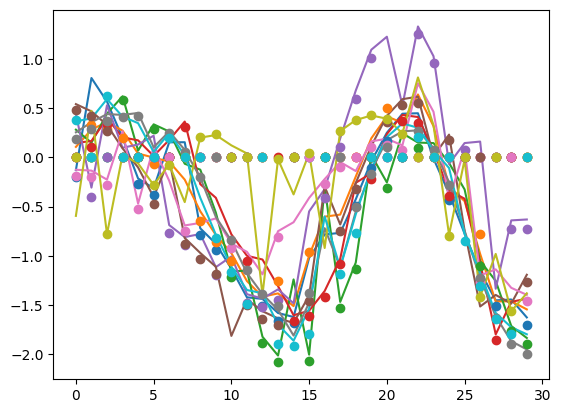

In [823]:
import torch

qz_x = gpvae.model.backbone.encode(torch.tensor(X).float())
z = qz_x.mean
X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[0])
plt.gca().set_prop_cycle(None)
plt.plot(X[0],'o')
plt.show();

In [827]:
from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
gpvae.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)
#gpvae.gp.p = 0.1 # ratio of imputation of the dataset
gpvae.fit_kernel(dataset_train)  # train the model to learn the kernel parameters

## Visualisation: embed the first 10 time series, use the GP scheme to correct, and plot reconstruction

In [830]:
X_torch = torch.tensor(X).float()[:10]
embedding = gpvae.model.backbone.encode(X_torch)
imputed_data = gpvae.gp.infer(embedding, X_torch)
X_recon = gpvae.model.backbone.decode(embedding.mean).mean

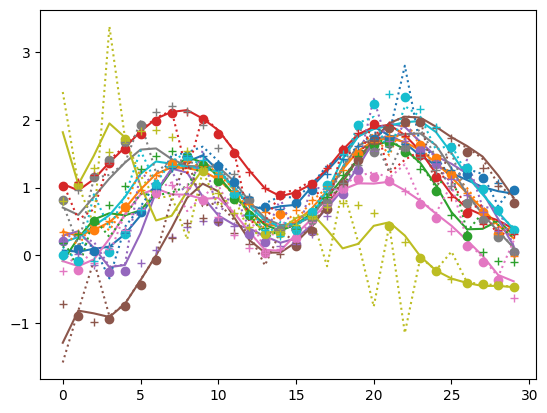

In [835]:
i = 2 ## reconstruct time series number i
X_torch[X_torch==0] = torch.nan
plt.plot(imputed_data[i].detach(), label = 'mean reconstruction with GP')
plt.gca().set_prop_cycle(None)
plt.plot(X_recon[i].detach(), ':', label = 'mean reconstruction without GP')
plt.gca().set_prop_cycle(None)
plt.plot(X_torch[i].detach(), 'o', label = 'observed data');
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i], '+', label = 'missing data');
plt.legend()